In [1]:
import time
start_time=time.time()


VIENTO pipeline

- Velocity Field
- Structure Function B(r) computation
- B(r) fit parameter ( 3 and 5 -parameter model) and confidence intervals determination
- Comparison between different results
- See what we have, what it is needed, if works, etc.

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import save_modelresult


# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

import strucfunc                   
#import ci_results_compiler
import fit_structure_function
import bfunc
#import bplot
#import bplot_ideal

# Loading velocity field

In [3]:
name = 'fake_map_mod_finite_m2.85_r32_N512'

In [4]:
hdul = fits.open('fake_maps_data/' + name + '.fits')

m2D      = hdul[0].header['M2D']
ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']


In [5]:
vv = hdul[0].data.astype(float)

# Computing structure function

In [6]:
Br = strucfunc.strucfunc_numba_parallel(vv, wmap=None, dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\pipeline_VIENTO\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\pipeline_VIENTO\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


# Fitting and confidence intervals

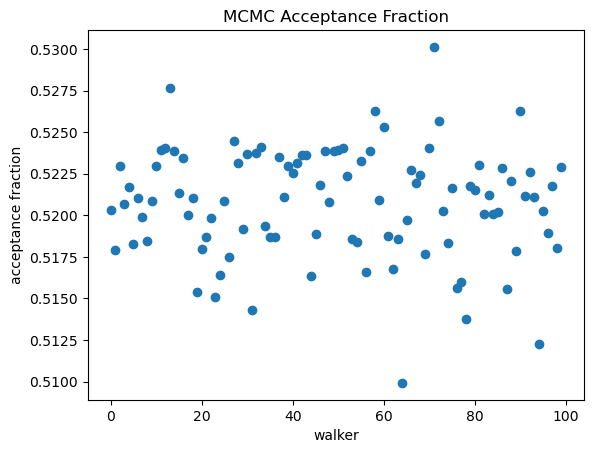

Autocorrelation time for the parameters:
----------------------------------------
r0 = 66.338
sig2 = 67.522
m = 66.316
s0 = 79.988
noise = 97.851


In [7]:
fit_Br = fit_structure_function.fit_structure_function(Br, box_size, bfunc, name = 'Br', data = 'Br')

In [8]:
fit_Br

{'result': <lmfit.model.ModelResult at 0x219b83ad6d0>,
 'result_emcee': <lmfit.model.ModelResult at 0x219badef680>}

In [16]:
save_modelresult(fit_Br['result'], "result.sav")

In [17]:
save_modelresult(fit_Br['result_emcee'], "result_emcee.sav")

In [9]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 775.8700699806213 seconds ---
